Auditar calidad del dataset y validar consistencia

Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cargar dataset original

In [2]:
df = pd.read_csv("../data/raw/unesco_journalists.csv")

df.head()

,ID,Title En,Countries,Date,Nationality,Language,Gender,Enquiry status,Staff,Local,...,Coordinates,country_Geometry,Country UUID,Enquiry status home,Calc country code,calc_country,Geo Shape,Conflict zone calc,Enquiry status stat,Enquiry status min
0,3216,Jacinto Hernández Torres,US,2016-06-13,American,NaN,Male,Ongoing/Unresolved,Freelancer,Local,...,"38.9, -77.04","{""coordinates"": [[[[-170.64529, -14.253225], [...",d34dfe37-237c-5dc1-9474-ec0389282d59,Ongoing/Unresolved,US,Jacinto Hernández Torres,"{""coordinates"": [[[[-170.64529, -14.253225], [...",Not a Conflict Zone,Ongoing/Unresolved,Ongoing/Unresolved
1,2717,Alexander Álvarez Ramírez,PY,2023-02-14,Paraguayan,NaN,Male,Ongoing/Unresolved,Staff,Local,...,"-25.28, -57.63","{""coordinates"": [[[-58.168511, -20.172243], [-...",7b505d08-ca4c-5e37-bae6-0f2641524c16,Ongoing/Unresolved,PY,Alexander Álvarez Ramírez,"{""coordinates"": [[[-58.168511, -20.172243], [-...",Not a Conflict Zone,Ongoing/Unresolved,Ongoing/Unresolved
2,2741,Humberto Andrés Coronel Godoy,PY,2022-09-12,Paraguayan,NaN,Male,Ongoing/Unresolved,Not indicated,Local,...,"-25.28, -57.63","{""coordinates"": [[[-58.168511, -20.172243], [-...",7b505d08-ca4c-5e37-bae6-0f2641524c16,Ongoing/Unresolved,PY,Humberto Andrés Coronel Godoy,"{""coordinates"": [[[-58.168511, -20.172243], [-...",Not a Conflict Zone,Ongoing/Unresolved,Ongoing/Unresolved
3,2749,Fredid Román,MX,2022-08-22,Mexican,NaN,Male,Ongoing/Unresolved,Staff,Local,...,"19.35, -99.14","{""coordinates"": [[[-97.146616, 25.956231], [-9...",c44c1951-6317-55e6-acdc-bb74ab699002,Ongoing/Unresolved,MX,Fredid Román,"{""coordinates"": [[[-97.146616, 25.956231], [-9...",Not a Conflict Zone,Ongoing/Unresolved,Ongoing/Unresolved
4,2752,Alejandro Arriaga,MX,2022-08-11,Mexican,NaN,Male,Ongoing/Unresolved,Not indicated,Local,...,"19.35, -99.14","{""coordinates"": [[[-97.146616, 25.956231], [-9...",c44c1951-6317-55e6-acdc-bb74ab699002,Ongoing/Unresolved,MX,Alejandro Arriaga,"{""coordinates"": [[[-97.146616, 25.956231], [-9...",Not a Conflict Zone,Ongoing/Unresolved,Ongoing/Unresolved


Dimensiones del dataset

In [3]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 1864
Número de columnas: 41


Revisar nombres de columnas

In [4]:
df.columns.tolist()

['ID',
 'Title En',
 'Countries',
 'Date',
 'Nationality',
 'Language',
 'Gender',
 'Enquiry status',
 'Staff',
 'Local',
 'Conflict Zone',
 'Age',
 'Media',
 'Created At',
 'Updated At',
 'Date resolution',
 'UUID',
 'Document Id',
 'Published At',
 'Area coverage',
 'main_image',
 'dg_request',
 'state_acknowledgements',
 'state_response',
 'description_en',
 'description_fr',
 'description_es',
 'strapi_stage',
 'strapi_assignee',
 'País Título EN',
 'country_Regional Group',
 'Coordinates',
 'country_Geometry',
 'Country UUID',
 'Enquiry status home',
 'Calc country code',
 'calc_country',
 'Geo Shape',
 'Conflict zone calc',
 'Enquiry status stat',
 'Enquiry status min']

Tipos de datos

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1864 entries, 0 to 1863
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      1864 non-null   int64  
 1   Title En                1864 non-null   object 
 2   Countries               1861 non-null   object 
 3   Date                    1864 non-null   object 
 4   Nationality             1863 non-null   object 
 5   Language                0 non-null      float64
 6   Gender                  1864 non-null   object 
 7   Enquiry status          1655 non-null   object 
 8   Staff                   1855 non-null   object 
 9   Local                   1864 non-null   object 
 10  Conflict Zone           1864 non-null   bool   
 11  Age                     615 non-null    float64
 12  Media                   1864 non-null   object 
 13  Created At              1864 non-null   object 
 14  Updated At              1864 non-null   

Análisis de valores nulos

In [6]:
nulls = df.isnull().sum()

null_percentage = round(
    df.isnull().mean() * 100,
    2
)

missing_report = pd.DataFrame({

    "missing_values": nulls,

    "missing_percentage": null_percentage

})

missing_report.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_values,missing_percentage
Language,1864,100.00
description_fr,1864,100.00
description_es,1864,100.00
strapi_stage,1864,100.00
strapi_assignee,1864,100.00
main_image,1864,100.00
Area coverage,1804,96.78
Date resolution,1647,88.36
Age,1249,67.01
Enquiry status stat,209,11.21


Visualizar porcentaje de nulos

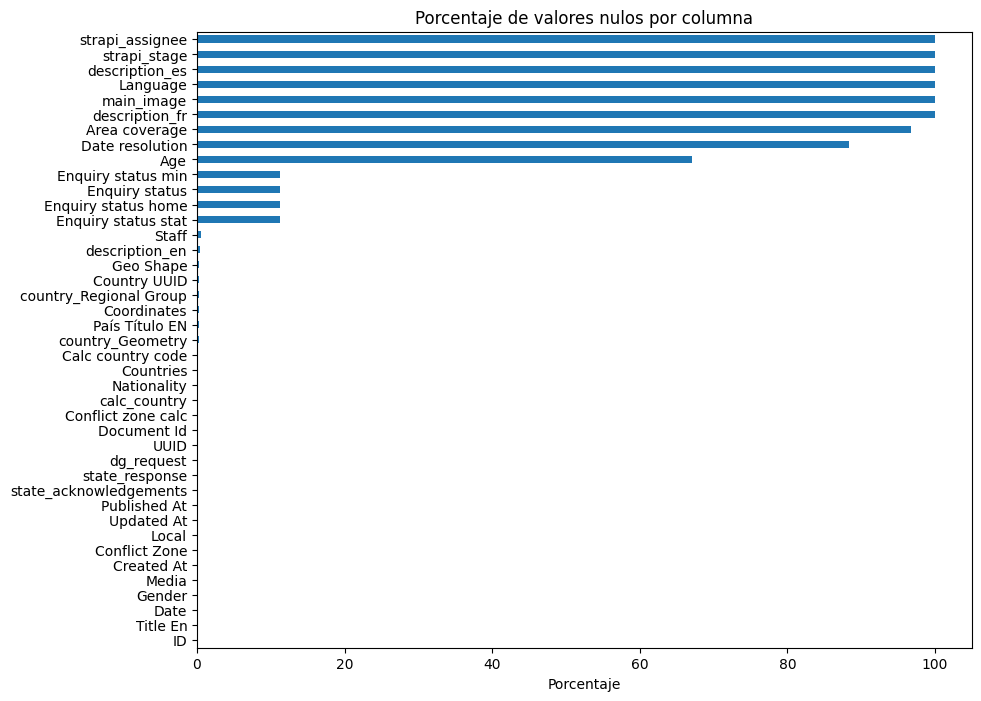

In [7]:
# Visualización de columnas con datos faltantes

missing_report.sort_values(
    "missing_percentage"
)["missing_percentage"].plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Porcentaje de valores nulos por columna")

plt.xlabel("Porcentaje")

plt.show()

Buscar duplicados

In [8]:
duplicates = df.duplicated().sum()

print("Registros duplicados:", duplicates)

Registros duplicados: 0


Revisar variables clave

In [9]:
columns_to_check = [

    "Media",
    "Gender",
    "Enquiry status",
    "Conflict Zone"

]

for col in columns_to_check:
    
    print("\nVariable:", col)
    
    print(df[col].value_counts(dropna=False))


Variable: Media
Media
Print             543
TV                527
Radio             346
Online            227
Cross-platform    221
Name: count, dtype: int64

Variable: Gender
Gender
Male      1721
Female     143
Name: count, dtype: int64

Variable: Enquiry status
Enquiry status
Ongoing/Unresolved                                                                                        1009
No Information Received So Far                                                                             249
Resolved                                                                                                   219
NaN                                                                                                        209
New request                                                                                                118
Unresolved – Archived                                                                                       37
Ongoing/Unresolved – Reported by Member State as kill

Cargar dataset procesado

In [10]:
cleaned = pd.read_csv(
    "../data/processed/cleaned_unesco.csv"
)

cleaned.head()

,ID,Title En,Countries,Date,Nationality,Gender,Enquiry status,Staff,Local,Conflict Zone,...,calc_country,Conflict zone calc,year,month,case_category,resolved,impunity,government_responded,primary_region,resolution_days
0,3216,Jacinto Hernández Torres,US,2016-06-13,American,Male,Ongoing/Unresolved,Freelancer,Local,False,...,Jacinto Hernández Torres,Not a Conflict Zone,2016,6,Unresolved,0,1,1,Europe and North America,NaN
1,2717,Alexander Álvarez Ramírez,PY,2023-02-14,Paraguayan,Male,Ongoing/Unresolved,Staff,Local,False,...,Alexander Álvarez Ramírez,Not a Conflict Zone,2023,2,Unresolved,0,1,1,Latin America and the Caribbean,NaN
2,2741,Humberto Andrés Coronel Godoy,PY,2022-09-12,Paraguayan,Male,Ongoing/Unresolved,Not indicated,Local,False,...,Humberto Andrés Coronel Godoy,Not a Conflict Zone,2022,9,Unresolved,0,1,1,Latin America and the Caribbean,NaN
3,2749,Fredid Román,MX,2022-08-22,Mexican,Male,Ongoing/Unresolved,Staff,Local,False,...,Fredid Román,Not a Conflict Zone,2022,8,Unresolved,0,1,1,Latin America and the Caribbean,NaN
4,2752,Alejandro Arriaga,MX,2022-08-11,Mexican,Male,Ongoing/Unresolved,Not indicated,Local,False,...,Alejandro Arriaga,Not a Conflict Zone,2022,8,Unresolved,0,1,1,Latin America and the Caribbean,NaN


Revisar estructura final

In [11]:
cleaned.columns.tolist()

['ID',
 'Title En',
 'Countries',
 'Date',
 'Nationality',
 'Gender',
 'Enquiry status',
 'Staff',
 'Local',
 'Conflict Zone',
 'Age',
 'Media',
 'Date resolution',
 'dg_request',
 'state_acknowledgements',
 'state_response',
 'País Título EN',
 'country_Regional Group',
 'Coordinates',
 'Calc country code',
 'calc_country',
 'Conflict zone calc',
 'year',
 'month',
 'case_category',
 'resolved',
 'impunity',
 'government_responded',
 'primary_region',
 'resolution_days']

Comparación antes vs después

In [12]:
print("Dataset original:", df.shape)

print("Dataset procesado:", cleaned.shape)

Dataset original: (1864, 41)
Dataset procesado: (1864, 30)


# Hallazgos principales

Durante la auditoría inicial del dataset se identificaron los siguientes puntos:

- Existen múltiples columnas técnicas o metadata sin utilidad analítica.
- La variable Age presenta una alta cantidad de valores faltantes.
- La variable Date resolution tiene muchos valores nulos porque gran parte de casos siguen sin resolverse.
- No existen registros duplicados.
- El dataset procesado queda listo para análisis posteriores.

Conclusión:

El dataset presenta buena calidad general, aunque requiere limpieza previa y validación antes del análisis exploratorio.